# LNP Atlas Data Exploration

This notebook explores the LNP Atlas dataset ("https://lnp-atlas.kisti.re.kr/") and investigates whether encapsulation efficiency can be predicted from formulation characteristics.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Load Dataset

The dataset is loaded from the raw data directory.

In [2]:
data_path = Path("../data/raw/lnp_atlas_export_20260804_2319.csv")
df = pd.read_csv(data_path,encoding='latin1')
df.head()

,lnp_id,ionizable_lipid,peg_lipid,sterol_lipid,helper_lipid,lipid_molar_ratio,particle_size_nm_std,pdi_std,zeta_potential_mv_std,encapsulation_efficiency_percent_std,...,peg_lipid_smiles,sterol_lipid_smiles,helper_lipid_smiles,synthesis_info,bioactivity_profile,paper_title,paper_authors,paper_doi,paper_journal,paper_year
0,466,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,173.6,0.184,NaN,78.45,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0
1,467,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,182.6,0.209,NaN,88.62,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0
2,468,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,129.2,0.139,NaN,85.73,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0
3,469,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,125.4,0.155,NaN,85.71,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0
4,470,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,126.6,0.193,NaN,76.7,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0


## 3. Dataset Overview

Inspect the number of rows, columns and available variables.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   lnp_id                                1092 non-null   int64  
 1   ionizable_lipid                       1084 non-null   str    
 2   peg_lipid                             1046 non-null   str    
 3   sterol_lipid                          1046 non-null   str    
 4   helper_lipid                          1045 non-null   str    
 5   lipid_molar_ratio                     1092 non-null   str    
 6   particle_size_nm_std                  1049 non-null   str    
 7   pdi_std                               744 non-null    str    
 8   zeta_potential_mv_std                 326 non-null    str    
 9   encapsulation_efficiency_percent_std  639 non-null    str    
 10  loading_capacity_std                  933 non-null    str    
 11  target_type                 

### Observations

- The dataset contains 1092 formulations.
- The dataset contains 28 variables.
- Encapsulation efficiency appears to be available.

## 4. Missing Value Analysis

Identify variables with substantial missing information.

In [4]:
df.isna().sum().sort_values(ascending=False) 

zeta_potential_mv_std                   766
encapsulation_efficiency_percent_std    453
pdi_std                                 348
peg_lipid_smiles                        189
bioactivity_profile                     162
loading_capacity_std                    159
ionizable_lipid_smiles                  152
helper_lipid_smiles                      77
sterol_lipid_smiles                      49
helper_lipid                             47
peg_lipid                                46
sterol_lipid                             46
helper_lipid_original                    46
peg_lipid_original                       46
particle_size_nm_std                     43
sterol_lipid_original                    43
ionizable_lipid_original                  8
ionizable_lipid                           8
paper_journal                             5
paper_year                                5
paper_doi                                 5
target_type                               0
lnp_id                          

### Observations

- Zeta potential contains the largest number of missing values.
- Encapsulation efficiency is missing for 453 formulations.
- Particle size is nearly complete.

## 5. Encapsulation Efficiency Analysis

Investigate the target variable and determine whether it can be used for regression modelling.

In [5]:
df["encapsulation_efficiency_percent_std"].describe()

count     639
unique    373
top       ~85
freq       21
Name: encapsulation_efficiency_percent_std, dtype: object

### Observations

The variable is currently stored as an object rather than a numerical variable. This indicates that some values contain textual annotations (e.g. "~85").

In [6]:
df_ee = df.dropna(
    subset=["encapsulation_efficiency_percent_std"]
)

print(df_ee.shape)
df_ee.info()
df_ee.head()

(639, 28)
<class 'pandas.DataFrame'>
Index: 639 entries, 0 to 1091
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   lnp_id                                639 non-null    int64  
 1   ionizable_lipid                       639 non-null    str    
 2   peg_lipid                             639 non-null    str    
 3   sterol_lipid                          634 non-null    str    
 4   helper_lipid                          639 non-null    str    
 5   lipid_molar_ratio                     639 non-null    str    
 6   particle_size_nm_std                  629 non-null    str    
 7   pdi_std                               488 non-null    str    
 8   zeta_potential_mv_std                 248 non-null    str    
 9   encapsulation_efficiency_percent_std  639 non-null    str    
 10  loading_capacity_std                  597 non-null    str    
 11  target_type             

,lnp_id,ionizable_lipid,peg_lipid,sterol_lipid,helper_lipid,lipid_molar_ratio,particle_size_nm_std,pdi_std,zeta_potential_mv_std,encapsulation_efficiency_percent_std,...,peg_lipid_smiles,sterol_lipid_smiles,helper_lipid_smiles,synthesis_info,bioactivity_profile,paper_title,paper_authors,paper_doi,paper_journal,paper_year
0,466,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,173.6,0.184,NaN,78.45,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0
1,467,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,182.6,0.209,NaN,88.62,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0
2,468,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,129.2,0.139,NaN,85.73,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0
3,469,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,125.4,0.155,NaN,85.71,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0
4,470,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,126.6,0.193,NaN,76.7,...,CCCCCCCCCCCCCCOC(=O)CCOCCOCCOCCOCCOCCOCCOCCOCC...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: T...,animal_model: C57BL/6 mice; administration_rou...,Rational design and modular synthesis of biode...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0


### Observations

- After removing missing target values, 639 formulations remain to be used for modelling of encapsulation efficiency. 

## 6. Explore Target Variable Dataset

The original dataset contains formulations without a measured encapsulation efficiency value. Since supervised machine learning requires a target variable, formulations with missing encapsulation efficiency measurements are removed.

The resulting dataset will be used for all subsequent analyses and model development.

In [7]:
df_model = df.dropna(
    subset=["encapsulation_efficiency_percent_std"]
).copy()

print(f"Original dataset shape: {df.shape}")
print(f"Modeling dataset shape: {df_model.shape}")

Original dataset shape: (1092, 28)
Modeling dataset shape: (639, 28)


In [8]:
df_model["encapsulation_efficiency_percent_std"].value_counts().head(50)

encapsulation_efficiency_percent_std
~85            21
90             14
88             14
95             12
99             12
~90            11
96             11
~80            10
87             10
>85             9
98              9
84              8
91              7
89              6
85              6
92              6
72              6
74              5
97              5
82              5
65              4
76              4
86              4
94              4
45.5            4
~95             4
97.5            4
70              3
60              3
75.1            3
82.4 ¡¾ 3.3     3
68              3
58              3
32              3
42              3
18              3
10              3
89.8            3
93              3
78              3
97.6            3
48              3
40              3
75              3
79              3
60.3            3
2               3
20              3
73              2
78.3            2
Name: count, dtype: int64

## Target Variable Cleaning

The encapsulation efficiency variable contains a mixture of numerical values and textual annotations such as:

- approximate values (e.g. "~85")
- ranges (e.g. "90-95")
- threshold values (e.g. ">85")

To create a numerical target variable suitable for regression modelling, the following transformations are applied:

- Approximate values are converted to their numerical equivalent.
- Ranges are replaced by their midpoint.
- Threshold values are replaced by their reported threshold.
- Missing target values are removed. (--> Already performed)
- All values are depicted with two decimals after the comma. (float)

These assumptions preserve as much information as possible while maintaining a consistent numerical target variable.

In [9]:
import re
import numpy as np

def clean_encapsulation(value):

    value = str(value).strip()

    # ~85 -> 85
    value = value.replace("~", "")

    # Remove question marks
    value = value.replace("?", "")

    # 90-95 -> 92.5
    if "-" in value:
        try:
            low, high = value.split("-")
            return (float(low) + float(high)) / 2
        except:
            return np.nan

    # >90, >=90, <80, <=80
    value = re.sub(r"[<>≤≥=]", "", value)

    # Handle values such as "92.08 ± 2.5"
    match = re.match(r"^(\d+\.?\d*)", value)
    if match:
        return float(match.group(1))

    try:
        return float(value)
    except:
        return np.nan

In [10]:
df_model["encapsulation_efficiency"] = (
    df_model["encapsulation_efficiency_percent_std"]
    .apply(clean_encapsulation)
)

In [11]:
df_model["encapsulation_efficiency"].describe()
failed = df_model[df_model["encapsulation_efficiency"].isna()]
failed.head()

,lnp_id,ionizable_lipid,peg_lipid,sterol_lipid,helper_lipid,lipid_molar_ratio,particle_size_nm_std,pdi_std,zeta_potential_mv_std,encapsulation_efficiency_percent_std,...,sterol_lipid_smiles,helper_lipid_smiles,synthesis_info,bioactivity_profile,paper_title,paper_authors,paper_doi,paper_journal,paper_year,encapsulation_efficiency
566,885,C12-200,PE-PEG2000,cholesterol,DOPE,35:2.5:46.5:16,77.3-82.4 (microfluidic); 145.1 (bulk mixed),0.089-0.108 (microfluidic); 0.085 (bulk mixed),NaN,81.1-83.5 (microfluidic); 61.5 (bulk mixed),...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCC/C=C\CCCCCCCC(=O)OC[C@H](COP(=O)(O)OCC...,synthesis_method: Microfluidic; device_used: P...,animal_model: C57BL/6 mice; administration_rou...,Scalable mRNA and siRNA Lipid Nanoparticle Pro...,"['Sarah J. Shepherd', 'Claude C. Warzecha', 'S...",https://doi.org/10.1021/acs.nanolett.1c01353,Nano Letters,2021.0,NaN


### Observations
- One row was dropped because the cell contained information about two different states, which did not pass the clean_encapsulation function.
- 638 values of encapsulation efficiency were cleaned up and remain for modeling.

In [12]:
df_model["encapsulation_efficiency"].info()
df_model = df_model.dropna(
    subset=["encapsulation_efficiency"]
)
df_model["encapsulation_efficiency"].info()

<class 'pandas.Series'>
Index: 639 entries, 0 to 1091
Series name: encapsulation_efficiency
Non-Null Count  Dtype  
--------------  -----  
638 non-null    float64
dtypes: float64(1)
memory usage: 10.0 KB
<class 'pandas.Series'>
Index: 638 entries, 0 to 1091
Series name: encapsulation_efficiency
Non-Null Count  Dtype  
--------------  -----  
638 non-null    float64
dtypes: float64(1)
memory usage: 10.0 KB


## Encapsulation Efficiency Distribution
After cleaning the target variable, the distribution of encapsulation efficiency is inspected to identify potential outliers and assess whether the values fall within a realistic range.

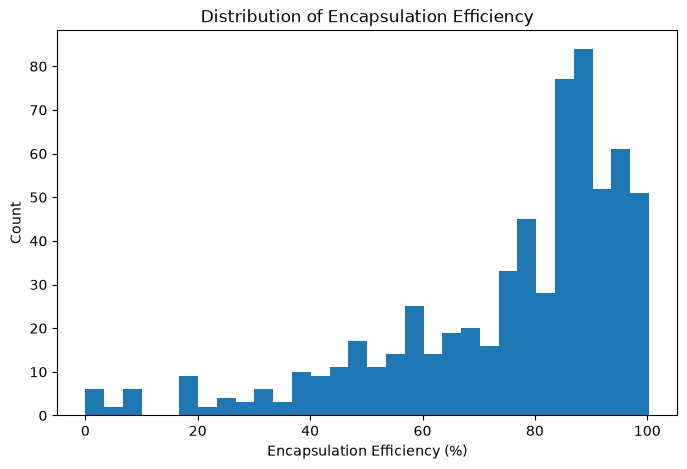

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    df_model["encapsulation_efficiency"],
    bins=30
)

plt.xlabel("Encapsulation Efficiency (%)")
plt.ylabel("Count")
plt.title("Distribution of Encapsulation Efficiency")
plt.show()


In [14]:
df_model["encapsulation_efficiency"].describe()

count    638.000000
mean      75.610376
std       21.578264
min        0.000000
25%       65.000000
50%       84.000000
75%       90.900000
max      100.300000
Name: encapsulation_efficiency, dtype: float64

C:\Users\irisb\AppData\Local\Temp\ipykernel_22216\2932063719.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


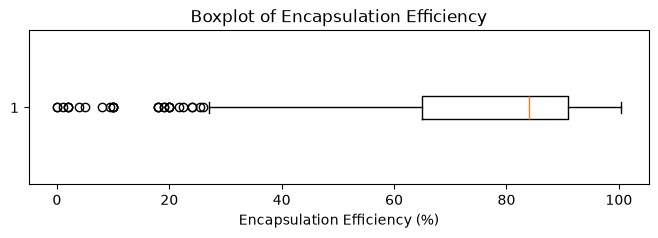

In [15]:
plt.figure(figsize=(8, 2))

plt.boxplot(
    df_model["encapsulation_efficiency"].dropna(),
    vert=False
)

plt.xlabel("Encapsulation Efficiency (%)")
plt.title("Boxplot of Encapsulation Efficiency")
plt.show()

In [16]:
df_model[df_model["encapsulation_efficiency"] > 100]

,lnp_id,ionizable_lipid,peg_lipid,sterol_lipid,helper_lipid,lipid_molar_ratio,particle_size_nm_std,pdi_std,zeta_potential_mv_std,encapsulation_efficiency_percent_std,...,sterol_lipid_smiles,helper_lipid_smiles,synthesis_info,bioactivity_profile,paper_title,paper_authors,paper_doi,paper_journal,paper_year,encapsulation_efficiency
341,524,Custom lipid,PEG-lipid,cholesterol,DSPC,50:38.5:10:1.5 (Estimated molar ratio 45-55:0-...,52.8,0.15,NaN,100.3,...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Ethanol-drop nanoprecipitati...,animal_model: CD-1 mice; administration_route:...,Discovery of a Novel Amino Lipid That Improves...,"['Mark Cornebise', 'Elisabeth Narayanan', 'Yan...",10.1002/adfm.202106727,Advanced Functional Materials,2022.0,100.3
352,535,Custom lipid,PEG-lipid,cholesterol,DSPC,50:38.5:10:1.5 (Estimated molar ratio 45-55:0-...,69.3,0.23,NaN,100.2,...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Ethanol-drop nanoprecipitati...,animal_model: CD-1 mice; administration_route:...,Discovery of a Novel Amino Lipid That Improves...,"['Mark Cornebise', 'Elisabeth Narayanan', 'Yan...",10.1002/adfm.202106727,Advanced Functional Materials,2022.0,100.2


In [17]:
df_model[df_model["encapsulation_efficiency"] == 0]

,lnp_id,ionizable_lipid,peg_lipid,sterol_lipid,helper_lipid,lipid_molar_ratio,particle_size_nm_std,pdi_std,zeta_potential_mv_std,encapsulation_efficiency_percent_std,...,sterol_lipid_smiles,helper_lipid_smiles,synthesis_info,bioactivity_profile,paper_title,paper_authors,paper_doi,paper_journal,paper_year,encapsulation_efficiency
971,710,DLin-KC2-DMA,PEG-c-DMA,cholesterol,DSPC,80:5:3.5:11.5,33,NaN,NaN,0,...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCCCCCCCCCCCC(=O)OC[C@H](COP(=O)([O-])OCC...,synthesis_method: Microfluidic; device_used: s...,NaN,Microfluidic Mixing: A General Method for Enca...,"['Alex K. K. Leung', 'Yuen Yi C. Tam', 'Sam Ch...",10.1021/acs.jpcb.5b02891,The Journal of Physical Chemistry B,2015.0,0.0
972,711,DLin-KC2-DMA,PEG-c-DMA,cholesterol,DOPE,80:5:3.5:11.5,32,NaN,NaN,0,...,C[C@H](CCCC(C)C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3...,CCCCCCCC/C=C\CCCCCCCC(=O)OC[C@H](COP(=O)(O)OCC...,synthesis_method: Microfluidic; device_used: s...,NaN,Microfluidic Mixing: A General Method for Enca...,"['Alex K. K. Leung', 'Yuen Yi C. Tam', 'Sam Ch...",10.1021/acs.jpcb.5b02891,The Journal of Physical Chemistry B,2015.0,0.0


In [18]:
df_model = df_model[df_model["encapsulation_efficiency"] != 0].copy()
df_model.info()

<class 'pandas.DataFrame'>
Index: 636 entries, 0 to 1091
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   lnp_id                                636 non-null    int64  
 1   ionizable_lipid                       636 non-null    str    
 2   peg_lipid                             636 non-null    str    
 3   sterol_lipid                          631 non-null    str    
 4   helper_lipid                          636 non-null    str    
 5   lipid_molar_ratio                     636 non-null    str    
 6   particle_size_nm_std                  626 non-null    str    
 7   pdi_std                               487 non-null    str    
 8   zeta_potential_mv_std                 248 non-null    str    
 9   encapsulation_efficiency_percent_std  636 non-null    str    
 10  loading_capacity_std                  594 non-null    str    
 11  target_type                       

### Observations

After cleaning, 636 valid encapsulation efficiency measurements remained available for analysis.

The distribution appears realistic, with a median encapsulation efficiency of 84% and most formulations achieving efficiencies above 65%.

Two formulations exhibited an encapsulation efficiency slightly above 100% (100.3% and 100.2%), likely reflecting experimental or rounding variability. This observation was retained for the current analysis as its impact on model development is expected to be negligible.

Two observations reported an encapsulation efficiency of 0%.
A manual inspection of the corresponding source publications did not confirm these values. As they are likely the result of data extraction or transcription errors, these observations were removed from the modeling dataset. 

## 7. Feature Exploration

Possible categorical features: 
    ionizable_lipid
    helper_lipid
    sterol_lipid  
    peg_lipid
    target_type

Possible numerical features:
    lipid_molar_ratio
    particle_size_nm_std
    pdi_std
    loading_capacity_std
    

## Cleaning of numerical features

In [19]:
df_model["lipid_molar_ratio"].sample(20)

737                                            79:1:10:10
702                                        35:2.5:46.5:16
91                                         35:2.5:46.5:16
961                                        70:1:17.5:11.5
962                                        70:1:17.5:11.5
813                                        35:16:46.5:2.5
977                                        50:1:37.5:11.5
529                                        35:46.5:16:2.5
1028                                       50:1.5:38.5:10
1024                                       50:1.5:38.5:10
16                                     52.7:1.1:28.7:17.5
98                                         35:2.5:46.5:16
290                                        50:10:38.5:1.5
873                                        35:16:46.5:2.5
216                                        50:10:38.5:1.5
955                                        60:1:27.5:11.5
344     50:38.5:10:1.5 (Estimated molar ratio 45-55:0-...
370     50:38.

The lipid molar ratio contains the relative proportions of the four major lipid components within the formulation. Since machine learning models cannot directly interpret ratio strings, the molar ratio was decomposed into four numerical features representing the proportion of each formulation component (see catgorical features: ionizable_lipid, helper_lipid, sterol_lipid, peg_lipid).

In [20]:
df_model["lipid_molar_ratio_clean"] = (
    df_model["lipid_molar_ratio"]
    .str.split("(")
    .str[0]
    .str.strip()
)
df_model[
    ["lipid_molar_ratio", "lipid_molar_ratio_clean"]
].sample(20, random_state=42)


,lipid_molar_ratio,lipid_molar_ratio_clean
341,50:38.5:10:1.5 (Estimated molar ratio 45-55:0-...,50:38.5:10:1.5
1082,30:2:48:20,30:2:48:20
124,35:2.5:46.5:16,35:2.5:46.5:16
539,35:46.5:16:2.5,35:46.5:16:2.5
190,35:2.5:46.5:16,35:2.5:46.5:16
1023,50:1.5:38.5:10,50:1.5:38.5:10
96,35:2.5:46.5:16,35:2.5:46.5:16
128,35:2.5:46.5:16,35:2.5:46.5:16
994,80:1:7.5:11.5,80:1:7.5:11.5
272,50:10:38.5:5,50:10:38.5:5


In [21]:
ratios = (
    df_model["lipid_molar_ratio_clean"]
    .str.split(":", expand=True)
)

df_model["lipid_molar_ratio_clean"].value_counts()

lipid_molar_ratio_clean
35:2.5:46.5:16        123
50:1.5:38.5:10         62
35:16:46.5:2.5         52
50:10:38.5:1.5         43
50:38.5:10:1.5         41
                     ... 
51:10:39:1.5            1
51:10:39:5              1
51:10:39:10             1
50:0.75:38.5:10.75      1
57.1:7.1:34.3:1.4       1
Name: count, Length: 146, dtype: int64

In [22]:
ratios[
    ratios.apply(
        lambda col: col.str.contains(r"\+", na=False)
    ).any(axis=1)
]
df_model[df_model["lipid_molar_ratio_clean"] == "15:2:25:20+62"]

,lnp_id,ionizable_lipid,peg_lipid,sterol_lipid,helper_lipid,lipid_molar_ratio,particle_size_nm_std,pdi_std,zeta_potential_mv_std,encapsulation_efficiency_percent_std,...,helper_lipid_smiles,synthesis_info,bioactivity_profile,paper_title,paper_authors,paper_doi,paper_journal,paper_year,encapsulation_efficiency,lipid_molar_ratio_clean
221,850,Custom lipid,DMG-PEG2000,cholesterol,DOPE + DOTAP,15:2:25:20+62,95,0.1,NaN,~90,...,CCCCCCCC/C=C\CCCCCCCC(=O)OCC(C[N+](C)(C)C)OC(=...,synthesis_method: Ethanol dilution; device_use...,cell_line: IGROV1; animal_model: C57BL/6 mice;...,Reformulating lipid nanoparticles for organ-ta...,"['Kexin Su', 'Lu Shi', 'Tao Sheng', 'Xinxin Ya...",https://doi.org/10.1038/s41467-024-50093-7,Nature Communications,2024.0,90.0,15:2:25:20+62


In [23]:
df_model = df_model[
    df_model["lipid_molar_ratio_clean"] != "15:2:25:20+62"
].copy()
print(df_model.shape)

ratios = (
    df_model["lipid_molar_ratio_clean"]
    .str.split(":", expand=True)
)

ratios.columns = ["ionizable_ratio","helper_ratio","sterol_ratio","peg_ratio"]

df_model["lipid_molar_ratio_clean"].value_counts()

ratios = ratios.astype(float)

mask = ratios["peg_ratio"] > ratios["helper_ratio"] #check where peg ratio is higher than helper ratio: assume this to be incorrect: needs to be swapped

print(f"Swapping helper and PEG ratios for {mask.sum()} rows.")

ratios.loc[mask, ["helper_ratio", "peg_ratio"]] = (
    ratios.loc[mask, ["peg_ratio", "helper_ratio"]].values
)
print(
    f"Remaining rows with PEG > helper: "
    f"{(ratios['peg_ratio'] > ratios['helper_ratio']).sum()}"
)

(635, 30)
Swapping helper and PEG ratios for 407 rows.
Remaining rows with PEG > helper: 0


In [24]:
# Add ratios back to the dataframe
df_model = pd.concat([df_model, ratios], axis=1)

df_model.head()

,lnp_id,ionizable_lipid,peg_lipid,sterol_lipid,helper_lipid,lipid_molar_ratio,particle_size_nm_std,pdi_std,zeta_potential_mv_std,encapsulation_efficiency_percent_std,...,paper_authors,paper_doi,paper_journal,paper_year,encapsulation_efficiency,lipid_molar_ratio_clean,ionizable_ratio,helper_ratio,sterol_ratio,peg_ratio
0,466,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,173.6,0.184,NaN,78.45,...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0,78.45,50:1.5:38.5:10,50.0,10.0,38.5,1.5
1,467,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,182.6,0.209,NaN,88.62,...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0,88.62,50:1.5:38.5:10,50.0,10.0,38.5,1.5
2,468,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,129.2,0.139,NaN,85.73,...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0,85.73,50:1.5:38.5:10,50.0,10.0,38.5,1.5
3,469,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,125.4,0.155,NaN,85.71,...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0,85.71,50:1.5:38.5:10,50.0,10.0,38.5,1.5
4,470,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,126.6,0.193,NaN,76.7,...,"['Yue Xu', 'Fanglin Gong', 'Alex Golubovic', '...",https://doi.org/10.1073/pnas.2409572122,PNAS,2025.0,76.70,50:1.5:38.5:10,50.0,10.0,38.5,1.5


In [25]:
df_model["ratio_sum"] = (
    df_model["ionizable_ratio"]
    + df_model["helper_ratio"]
    + df_model["sterol_ratio"]
    + df_model["peg_ratio"]
)

df_model["ratio_sum"].describe()

count    635.000000
mean     100.454409
std        6.532921
min       22.000000
25%      100.000000
50%      100.000000
75%      100.000000
max      165.000000
Name: ratio_sum, dtype: float64

In [26]:
df_model[
    (df_model["ratio_sum"] < 95) |
    (df_model["ratio_sum"] > 105)
][
    [
        "lnp_id",
        "lipid_molar_ratio",
        "ionizable_ratio",
        "helper_ratio",
        "sterol_ratio",
        "peg_ratio",
        "ratio_sum"
    ]
].sort_values("ratio_sum")

,lnp_id,lipid_molar_ratio,ionizable_ratio,helper_ratio,sterol_ratio,peg_ratio,ratio_sum
887,430,16:1:4:1,16.0,1.0,4.0,1.00,22.00
277,770,50:10:5:5,50.0,10.0,5.0,5.00,70.00
222,851,50:0.2:0:40,50.0,40.0,0.0,0.20,90.20
633,179,20:0.75:40:30,20.0,30.0,40.0,0.75,90.75
770,955,35:2.5:37.5:16,35.0,16.0,37.5,2.50,91.00
771,956,35:2.5:37.5:16,35.0,16.0,37.5,2.50,91.00
768,953,35:2.5:37.5:16,35.0,16.0,37.5,2.50,91.00
767,952,35:2.5:37.5:16,35.0,16.0,37.5,2.50,91.00
765,950,35:2.5:37.5:16,35.0,16.0,37.5,2.50,91.00
769,954,35:2.5:37.5:16,35.0,16.0,37.5,2.50,91.00


In [27]:
df_model = df_model[
    (df_model["ratio_sum"] >= 95) &
    (df_model["ratio_sum"] <= 105)
].copy()
df_model.info()

<class 'pandas.DataFrame'>
Index: 603 entries, 0 to 1091
Data columns (total 35 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   lnp_id                                603 non-null    int64  
 1   ionizable_lipid                       603 non-null    str    
 2   peg_lipid                             603 non-null    str    
 3   sterol_lipid                          603 non-null    str    
 4   helper_lipid                          603 non-null    str    
 5   lipid_molar_ratio                     603 non-null    str    
 6   particle_size_nm_std                  593 non-null    str    
 7   pdi_std                               455 non-null    str    
 8   zeta_potential_mv_std                 223 non-null    str    
 9   encapsulation_efficiency_percent_std  603 non-null    str    
 10  loading_capacity_std                  572 non-null    str    
 11  target_type                       

### Molar Ratio - Observations
The lipid molar ratio was reported as a colon-separated string describing the relative proportions of the formulation components. In some records, additional explanatory text was appended to the ratio.

Prior to feature engineering, explanatory text was removed and the lipid ratios were separated into individual numerical variables representing the relative proportions of the formulation components.

One formulation was identified with a non-standard composition, containing two helper lipids (DOPE and DOTAP) represented as a combined ratio ("20+62"), resulting in a lipid molar ratio structure that was not directly comparable to the remaining formulations. As this observation represented a unique formulation format and could not be reliably transformed using the same feature engineering approach as the rest of the dataset, it was excluded from the modeling dataset.

The lipid molar ratio was decomposed into individual component ratios. As lipid molar ratios are expected to sum approximately to 100%, a validation step was performed by calculating the total ratio for each formulation.
A small number of formulations exhibited totals substantially different from 100%, indicating either non-standard reporting formats or potential data extraction inconsistencies.
For the initial modeling dataset, only formulations with a total lipid ratio between 95 and 105 were retained. This conservative filtering step ensures a consistent feature representation while affecting only a small proportion of the available observations. --> 603 entries remained.

### Lipid Molar Ratio - Harmonization

Inspection of the lipid molar ratio feature revealed inconsistencies in the ordering of formulation components across the dataset.

Two common conventions were identified:
1. Ionizable : Helper : Sterol : PEG
2. Ionizable : PEG : Sterol : Helper

As PEG-lipids are typically included at relatively low molar percentages compared to helper lipids, the relative magnitude of these components was used as a validation criterion when parsing formulation ratios.

For formulations where the PEG ratio exceeded the helper lipid ratio, the ordering was assumed to follow the second convention and the corresponding values were swapped.
This harmonization step was performed to improve consistency of the derived formulation features while preserving the maximum number of observations for downstream modeling.

In [28]:
df_model["particle_size_nm_std"].sample(20)

86               214.6
903                 78
164       156.3 ¡¾ 5.1
692              74.42
399              189.5
1020               165
787              127.8
932                 89
1029               125
237                 77
91               145.8
31                  90
945                113
946                 82
19                  93
84               205.6
249     100.77 ¡¾ 1.75
340               84.3
1052             129.9
684             66-107
Name: particle_size_nm_std, dtype: str

In [29]:
import re
import numpy as np

def clean_particle_size(value):

    value = str(value).strip()

    # ~95 -> 95
    value = value.replace("~", "")

    # Keep only value before ± notation
    value = re.split(r"±|¡¾", value)[0].strip()

    # 66-107 -> 86.5
    if "-" in value:
        try:
            low, high = value.split("-")
            return (float(low) + float(high)) / 2
        except:
            return np.nan

    # >90, >=90, <80, <=80
    value = re.sub(r"[<>≤≥=]", "", value)

    # Handle values such as "92.08 ± 2.5"
    #match = re.match(r"^(\d+\.?\d*)", value)
    #if match:
        #return float(match.group(1))


    try:
        return float(value)
    except:
        return np.nan
    

In [30]:
df_model["particle_size_nm"] = (
    df_model["particle_size_nm_std"]
    .apply(clean_particle_size)
)

In [31]:
df_model[["particle_size_nm_std","particle_size_nm"]].sample(50)
df_model.describe()

df_model[
    df_model["particle_size_nm"].isna()
][["particle_size_nm_std"]].head(30)


,particle_size_nm_std
42,NaN
183,NaN
320,NaN
321,NaN
565,67.3-82.2 (microfluidic); 124.4 (bulk mixed)
708,19 (liposomes pH 4); 39.4 (electron-dense pH 4...
709,18.5 (liposomes pH 4); 47.6 (electron-dense pH...
710,17.2 (liposomes pH 4); 56.3 (electron-dense pH...
711,22.9 (liposomes pH 4); 47.3 (electron-dense pH...
712,30 (pH 4); 53 (pH 7.4)


In [32]:
# Create checkpoint
df_model_before_particle_size_filter = df_model.copy()

# Remove rows with missing particle size
df_model = df_model.dropna(subset=["particle_size_nm"]).copy()

In [33]:
df_model.describe()

,lnp_id,paper_year,encapsulation_efficiency,ionizable_ratio,helper_ratio,sterol_ratio,peg_ratio,ratio_sum,particle_size_nm
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,531.864261,2020.249141,76.364811,43.678179,17.334622,37.016151,1.997680,100.026632,113.265687
std,298.118963,4.105090,20.393227,10.542321,9.802133,12.306936,0.806951,0.376544,46.210413
min,1.000000,2005.000000,1.000000,19.000000,2.500000,2.500000,0.100000,99.000000,26.000000
25%,243.250000,2018.000000,65.525000,35.000000,10.000000,34.000000,1.500000,100.000000,82.585000
50%,533.500000,2022.000000,84.000000,40.000000,16.000000,38.500000,1.750000,100.000000,102.000000
75%,780.750000,2024.000000,91.000000,50.000000,16.000000,46.500000,2.500000,100.000000,140.750000
max,1092.000000,2025.000000,100.300000,94.000000,48.500000,57.500000,5.000000,105.000000,368.000000


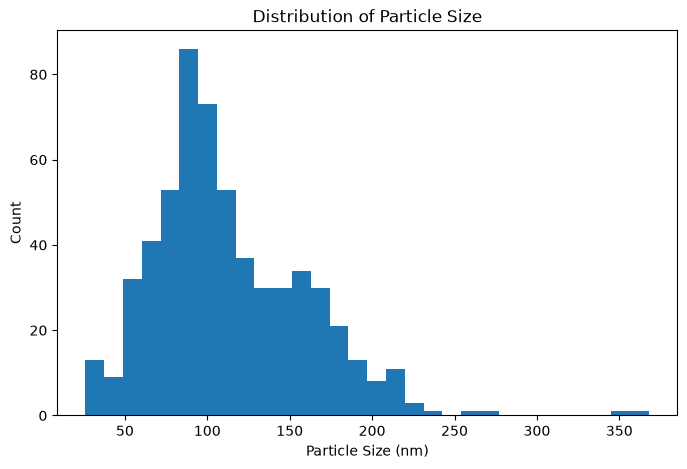

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    df_model["particle_size_nm"],
    bins=30
)

plt.xlabel("Particle Size (nm)")
plt.ylabel("Count")
plt.title("Distribution of Particle Size")

plt.show()

In [35]:
df_model[df_model["particle_size_nm"]>300]

,lnp_id,ionizable_lipid,peg_lipid,sterol_lipid,helper_lipid,lipid_molar_ratio,particle_size_nm_std,pdi_std,zeta_potential_mv_std,encapsulation_efficiency_percent_std,...,paper_journal,paper_year,encapsulation_efficiency,lipid_molar_ratio_clean,ionizable_ratio,helper_ratio,sterol_ratio,peg_ratio,ratio_sum,particle_size_nm
912,76,C12-200,C14-PEG2000,cholesterol,DOPC,40:0.5:55.5:4,352,0.2,NaN,18,...,Nano Letters,2015.0,18.0,40:0.5:55.5:4,40.0,4.0,55.5,0.5,100.0,352.0
917,81,C12-200,C14-PEG2000,cholesterol,DSPC,40:0.5:43.5:16,368,0.43,NaN,2,...,Nano Letters,2015.0,2.0,40:0.5:43.5:16,40.0,16.0,43.5,0.5,100.0,368.0


C:\Users\irisb\AppData\Local\Temp\ipykernel_22216\2561243006.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_model["particle_size_nm"], vert=False)


{'whiskers': [<matplotlib.lines.Line2D at 0x18714a3a850>,
 'caps': [<matplotlib.lines.Line2D at 0x18714a3aad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x18714a3a710>],
 'medians': [<matplotlib.lines.Line2D at 0x18714a3ad50>],
 'fliers': [<matplotlib.lines.Line2D at 0x18714a3ae90>],
 'means': []}

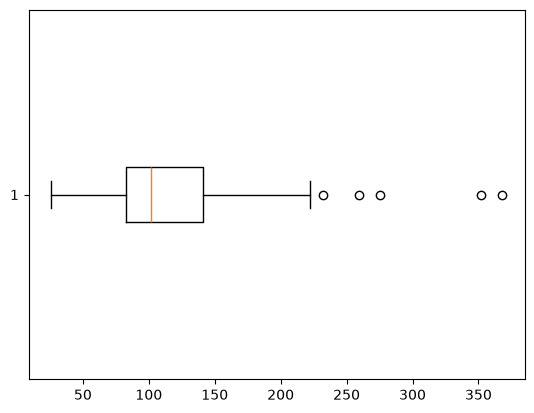

In [36]:
plt.boxplot(df_model["particle_size_nm"], vert=False)

### Particle Size - Observations

Particle size values were reported using several formats, including measurements accompanied by standard deviations (e.g. "156.3 ± 5.1").
To obtain a numerical feature suitable for machine learning, only the reported mean particle size was retained.

A small number of formulations (10) contained missing particle size measurements, these formulations were removed rather than imputed to avoid introducing artificial values into the dataset.

A small number of formulations reported multiple particle size measurements obtained under different experimental conditions (e.g. different pH values, measurement methods, or preparation techniques). Because a consistent rule for selecting one measurement could not be established without manual review of the source publications, these observations were excluded from the modeling dataset. --> 582 entries remaining

A small number of formulations exhibited particle sizes greater than 300 nm.These observations were retained in the modeling dataset because:
- the reported measurements appear valid,
- the lipid compositions are consistent,
- the observations originate from published experimental studies,
- no evidence of data extraction errors was identified.
As these formulations may represent genuinely poor-performing formulations (low encapsulation efficiency), they could provide useful information to the predictive model.

In [37]:
#df_model.info()
#df_model["pdi_std"].sample(20)
df_model["loading_capacity_std"].sample(20)

978                           CR:0.25(charge)[mRNA:lipid]
298          NP:5.67(molar), mRNA concentration 10 ng/¥ìL
945                             WR:5(wt/wt)[C12-200:mRNA]
258     OTHER:10:1 ratio of ionizable lipid: mRNA weig...
880          0.029 mg DNA per ¥ìmol lipid (NP:6.0(molar))
807                              WR:10(wt/wt)[lipid:mRNA]
788                              WR:10(wt/wt)[lipid:mRNA]
36                                            NP:6(molar)
98                OTHER:b-DNA:FLuc mRNA weight ratio 10:1
338                                         NP:3.4(molar)
987                          CR:0.25(charge)[siRNA:lipid]
195                                          NP:10(molar)
233                                           NP:6(molar)
1024                       WR:5(wt/wt)[synth_lipid:siRNA]
679                    WR:20(wt/wt)[ionizable_lipid:mRNA]
238                             WR:0.05(wt/wt)[mRNA:lipi]
1033                       WR:5(wt/wt)[synth_lipid:siRNA]
1051          

### PDI Feature Assessment - Observations

The polydispersity index (PDI) was available for 448 of 582 formulations, corresponding to approximately 77% data completeness.

Because more than 20% of the observations were missing PDI measurements, the feature was not included in the initial baseline model. This decision allows retention of the full modeling dataset while establishing baseline model performance.

The potential contribution of PDI will be investigated in a later modeling iteration using the subset of formulations for which PDI measurements are available.

## 8. Final Feature Selection for Baseline Model

## Numerical Features

In [38]:
features = [
    "ionizable_ratio",
    "helper_ratio",
    "sterol_ratio",
    "peg_ratio",
    "particle_size_nm"
]

target = "encapsulation_efficiency"

df_final_num = df_model[features + [target]].copy()

In [39]:
df_final_num.info()
df_final_num.describe()
#df_final_num.isna().sum()

<class 'pandas.DataFrame'>
Index: 582 entries, 0 to 1082
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ionizable_ratio           582 non-null    float64
 1   helper_ratio              582 non-null    float64
 2   sterol_ratio              582 non-null    float64
 3   peg_ratio                 582 non-null    float64
 4   particle_size_nm          582 non-null    float64
 5   encapsulation_efficiency  582 non-null    float64
dtypes: float64(6)
memory usage: 31.8 KB


,ionizable_ratio,helper_ratio,sterol_ratio,peg_ratio,particle_size_nm,encapsulation_efficiency
count,582.000000,582.000000,582.000000,582.000000,582.000000,582.000000
mean,43.678179,17.334622,37.016151,1.997680,113.265687,76.364811
std,10.542321,9.802133,12.306936,0.806951,46.210413,20.393227
min,19.000000,2.500000,2.500000,0.100000,26.000000,1.000000
25%,35.000000,10.000000,34.000000,1.500000,82.585000,65.525000
50%,40.000000,16.000000,38.500000,1.750000,102.000000,84.000000
75%,50.000000,16.000000,46.500000,2.500000,140.750000,91.000000
max,94.000000,48.500000,57.500000,5.000000,368.000000,100.300000


<Axes: >

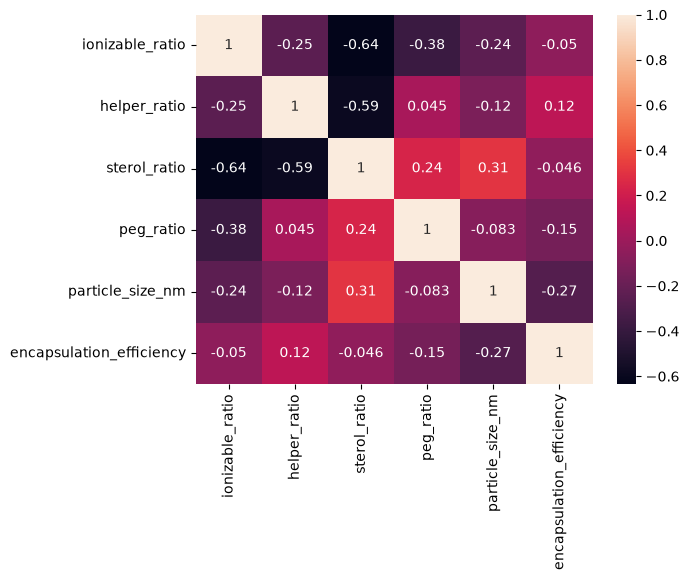

In [40]:
#visualize correlation
import seaborn as sns
sns.heatmap(
    df_final_num.corr(),
    annot=True
)

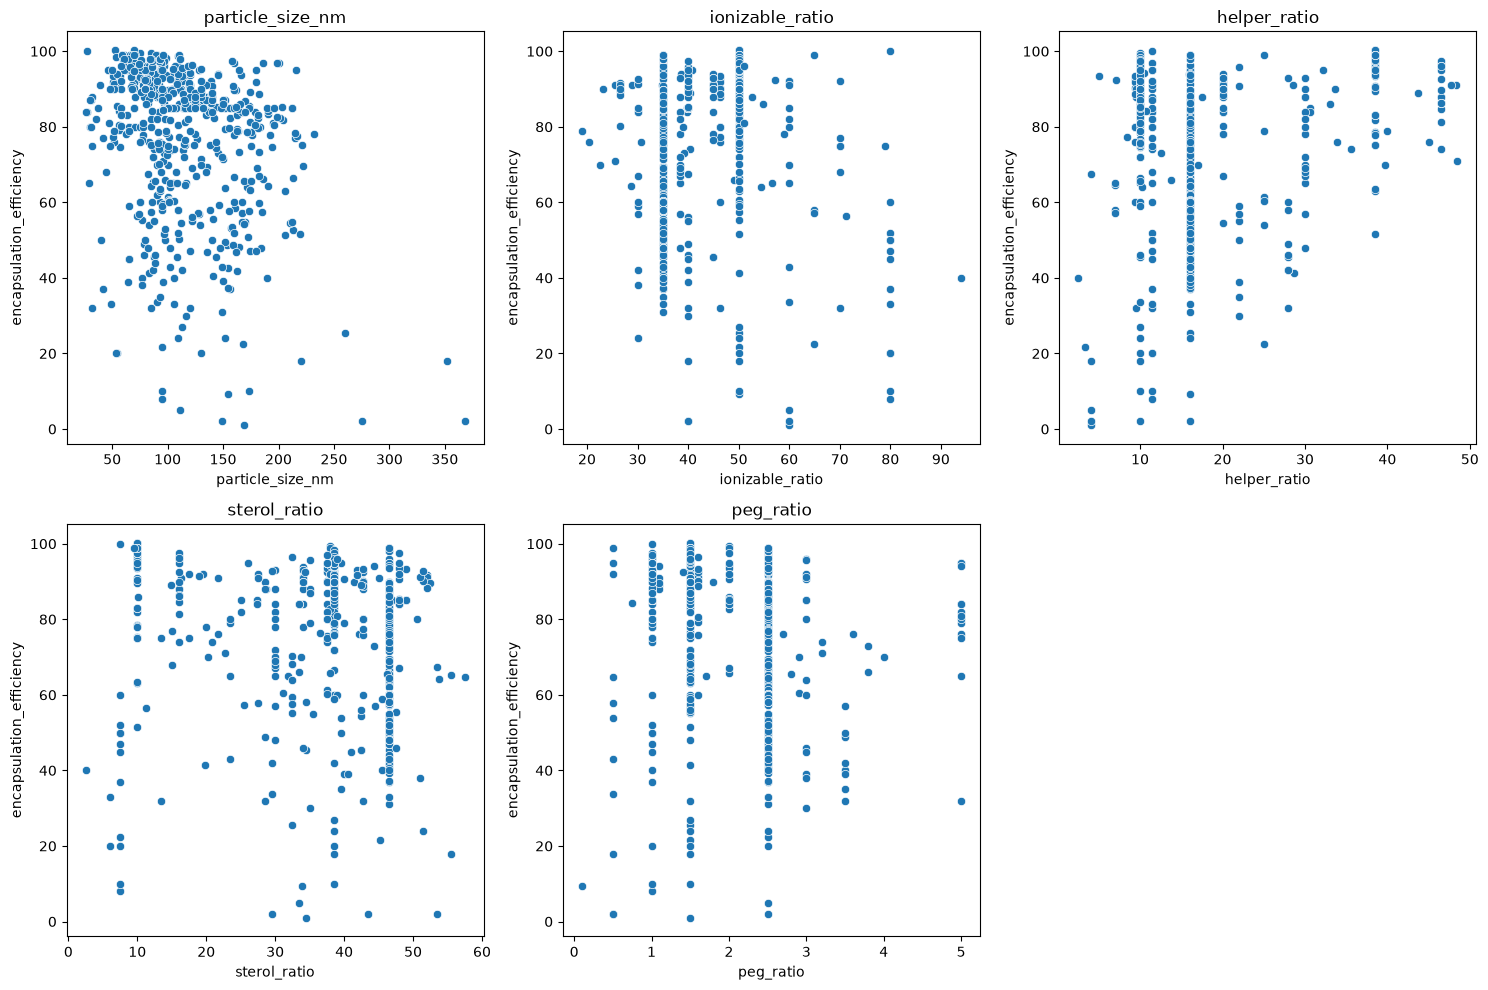

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "particle_size_nm",
    "ionizable_ratio",
    "helper_ratio",
    "sterol_ratio",
    "peg_ratio"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, feature in zip(axes.flatten(), features):

    sns.scatterplot(
        data=df_final_num,
        x=feature,
        y="encapsulation_efficiency",
        ax=ax
    )

    ax.set_title(feature)

# Remove unused subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

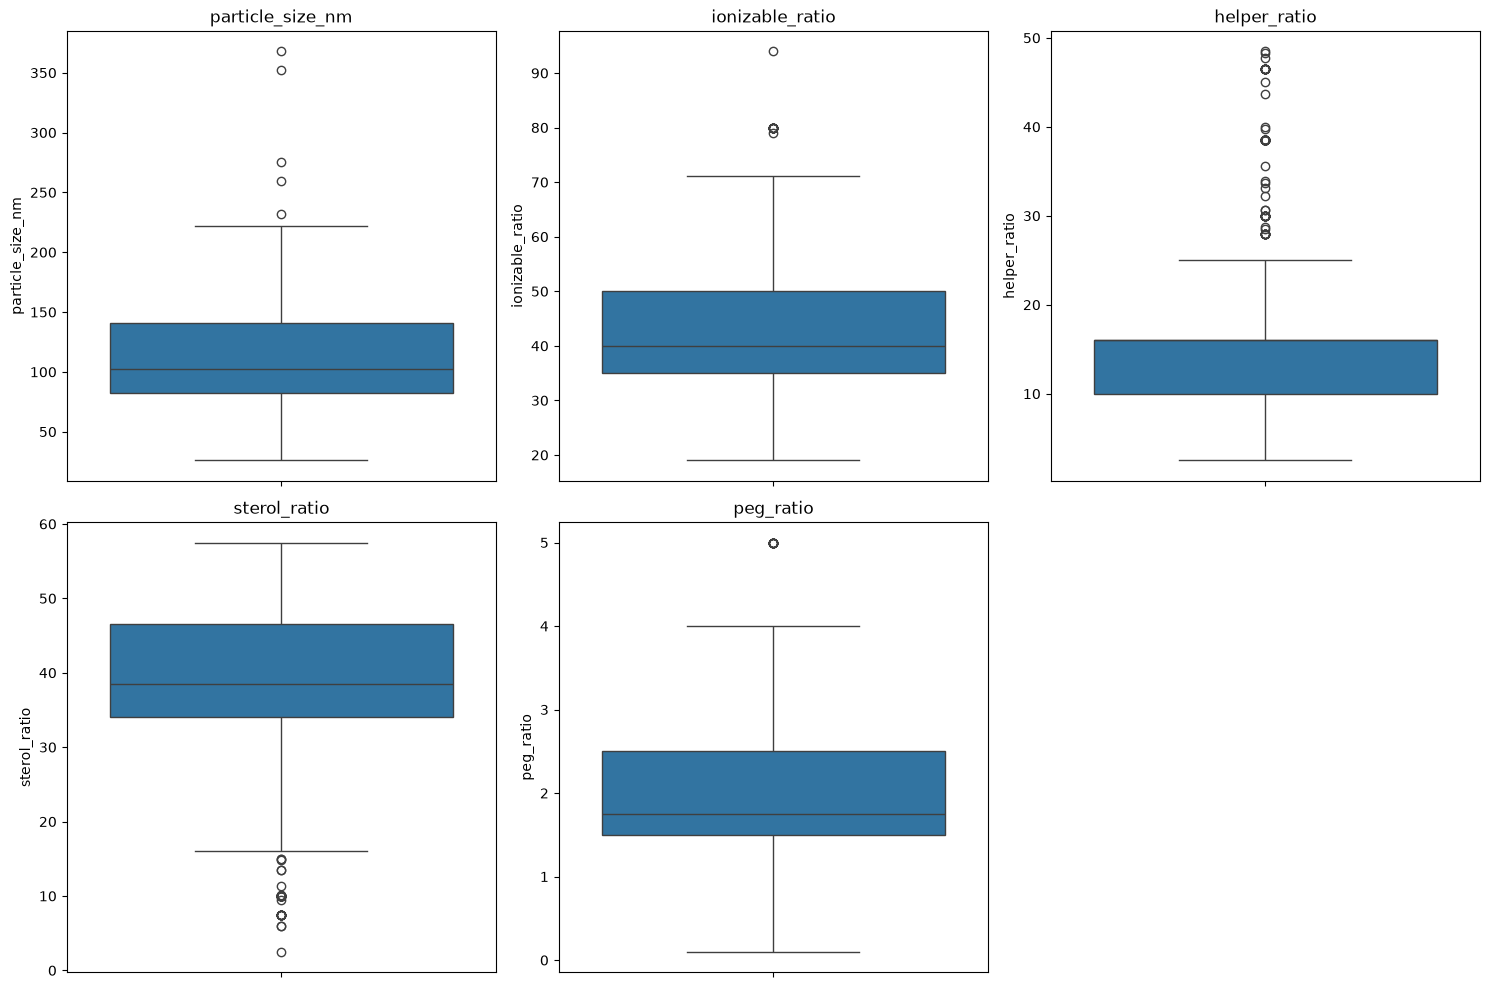

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, feature in zip(axes.flatten(), features):

    sns.boxplot(
        data=df_final_num,
        y=feature,
        ax=ax
    )

    ax.set_title(feature)

# Remove unused subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

## Final Numerical Feature Selection - Observations

Based on the exploratory analysis, a subset of features was selected for the baseline model.
The selected features include:
- Ionizable lipid ratio
- Helper lipid ratio
- Sterol ratio
- PEG-lipid ratio
- Particle size
PDI and zeta potential were excluded from the baseline model due to substantial missingness. Loading capacity was not included because of ambiguity.

### Correlation analysis:
The lipid ratio features exhibit substantial correlations with one another. This is expected because the lipid ratios represent compositional data and are constrained to sum to approximately 100%. Consequently, an increase in one lipid component is generally associated with a decrease in one or more of the remaining components.
Among the selected numerical features, the sterol-lipid ratio showed the strongest negative correlation with encapsulation efficiency. This suggests that formulations with higher PEG-lipid content tend to exhibit lower encapsulation efficiencies within the current dataset.

### Feature-Target Relationship:

Scatterplots were generated to visually assess the relationship between the selected numerical features and encapsulation efficiency.
No strong linear relationships were immediately apparent for any individual feature. This suggests that encapsulation efficiency is likely influenced by a combination of formulation variables rather than a single dominant predictor.

The absence of clear linear trends does not preclude the existence of non-linear relationships, which may be captured by more flexible machine learning models such as Random Forests.


## Categorical features